# 03 — Aggregation rules (Workstream 3)

Compare nine ways of collapsing same-day FinBERT story scores into one
firm-day signal on the FNSPID panel.

**Declared before any scoring**
- Primary outcome: `ar_open_h1` (stock open→next-open minus SPY; news already
  mapped to the Gate-1 next session, so this is the first post-map session).
- Primary horizon: h1 only (the panel does not yet carry longer horizons).
- Split: development ≤ 2019-12-31 for all fitting / ranking; evaluation
  ≥ 2020-01-01 is **not** used to choose a winner here.
- Inference: mean daily cross-sectional Spearman IC with **HAC(5)** SEs; portfolio
  mean net return via circular **block bootstrap** (length 5, seed recorded).
- Multiplicity family: nine aggregators × h1; Benjamini–Hochberg q = 0.05.
  n-bin strata are descriptive.
- Portfolio translation: one-session cross-sectional long/short, gross exposure 1,
  cost 10 bps/side on turnover; break-even bps reported. `negative_share` and
  `dispersion` are orientation-flipped (higher → short) from the estimand.

**Not in this notebook**
- Publisher-tier attention weights (blocked on checkpoint grain).
- Gate F1 RQ lock.
- Evaluation-block ranking (evaluation may be disclosed later; not used to pick a winner).

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import (  # noqa: E402
    AGGREGATOR_NAMES,
    MULTIPLICITY_FAMILY,
    PRIMARY_HORIZON,
    PRIMARY_OUTCOME,
    build_aggregation_panel,
    development_ic_table,
)
from final_experiments.lib.distribution import N_BIN_ORDER  # noqa: E402
from final_experiments.lib.evaluate import (  # noqa: E402
    DEFAULT_SIGNAL_ORIENT,
    TradeConfig,
    evaluate_aggregator_arms,
)
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_EVENTS_DB,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
)
from final_experiments.lib.plots import display_label  # noqa: E402

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PANEL_PATH = REPO_ROOT / "final_experiments" / "outputs" / "01_panel" / "fnspid_firm_day_panel.parquet"
print("panel:", PANEL_PATH)
print("events:", DEFAULT_EVENTS_DB)
print("output:", OUTPUT_DIR)
print(f"outcome={PRIMARY_OUTCOME}  horizon={PRIMARY_HORIZON}")
print(f"frozen split: development ≤ {FROZEN_DEV_END}; evaluation ≥ {FROZEN_EVAL_START}")
print("multiplicity:", MULTIPLICITY_FAMILY)

panel: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet
events: /Users/peterprendergast/Documents/Sentiment_Dissertation/reports/loop_moment2_finbert_20260719/finbert_checkpoint.sqlite3
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/03_aggregation
outcome=ar_open_h1  horizon=h1_open_to_open
frozen split: development ≤ 2019-12-31; evaluation ≥ 2020-01-01
multiplicity: nine aggregators × primary horizon h1; n-bin strata are descriptive, not additional family members


## 0. Build the nine firm-day signals

Story-level FinBERT scores → same-day rules → decayed state across each
symbol's news-bearing sessions. Headlines stay in the checkpoint DB.

In [2]:
panel = pd.read_parquet(PANEL_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
agg = build_aggregation_panel(panel, events_db=DEFAULT_EVENTS_DB)
print(
    f"rows={len(agg):,}  symbols={agg['symbol'].nunique():,}  "
    f"dev={int((agg['split']=='development').sum()):,}  "
    f"eval={int((agg['split']=='evaluation').sum()):,}"
)
assert set(AGGREGATOR_NAMES).issubset(agg.columns)
display(agg[["n", *AGGREGATOR_NAMES]].describe().T.round(4))

agg.to_parquet(OUTPUT_DIR / "firm_day_aggregators.parquet", index=False)
print("wrote", OUTPUT_DIR / "firm_day_aggregators.parquet")

rows=715,546  symbols=570  dev=512,153  eval=203,393


,count,mean,std,min,25%,50%,75%,max
n,715546.0,2.2353,2.5324,1.0000,1.0000,1.0000,3.0000,623.0000
mean_hard_label,715546.0,0.0764,0.5166,-1.0000,0.0000,0.0000,0.3333,1.0000
mean_continuous,715546.0,0.0808,0.4135,-0.9692,-0.0408,0.0410,0.2793,0.9452
median_continuous,715546.0,0.0799,0.4231,-0.9692,-0.0276,0.0347,0.2426,0.9466
trimmed_mean,715546.0,0.0808,0.4137,-0.9692,-0.0407,0.0411,0.2798,0.9452
negative_share,715546.0,0.1474,0.3025,0.0000,0.0000,0.0000,0.0000,1.0000
dispersion,715546.0,0.1649,0.2567,0.0000,0.0000,0.0000,0.3348,1.3475
strongest_event,715541.0,0.0833,0.5683,-0.9693,-0.0734,0.0472,0.5539,0.9468
attention_log_n,715546.0,0.0792,0.4024,-2.6218,-0.0362,0.0357,0.3322,2.1537
decayed_state,715546.0,0.1421,0.5180,-3.5055,-0.0397,0.0615,0.3872,3.6623


wrote /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet


## 1. How different are the rules?

Pairwise Spearman correlations on development firm-days. Near-collinear rules
will not give independent multiplicity draws even after BH.

,mean_hard_label,mean_continuous,median_continuous,trimmed_mean,negative_share,dispersion,strongest_event,attention_log_n,decayed_state
mean_hard_label,1.000,0.891,0.831,0.891,-0.666,-0.001,0.800,0.889,0.790
mean_continuous,0.891,1.000,0.959,1.000,-0.620,-0.020,0.902,0.986,0.852
median_continuous,0.831,0.959,1.000,0.959,-0.578,-0.030,0.836,0.935,0.820
trimmed_mean,0.891,1.000,0.959,1.000,-0.619,-0.020,0.901,0.987,0.852
negative_share,-0.666,-0.620,-0.578,-0.619,1.000,0.342,-0.568,-0.603,-0.568
dispersion,-0.001,-0.020,-0.030,-0.020,0.342,1.000,0.019,0.038,-0.029
strongest_event,0.800,0.902,0.836,0.901,-0.568,0.019,1.000,0.905,0.766
attention_log_n,0.889,0.986,0.935,0.987,-0.603,0.038,0.905,1.000,0.840
decayed_state,0.790,0.852,0.820,0.852,-0.568,-0.029,0.766,0.840,1.000


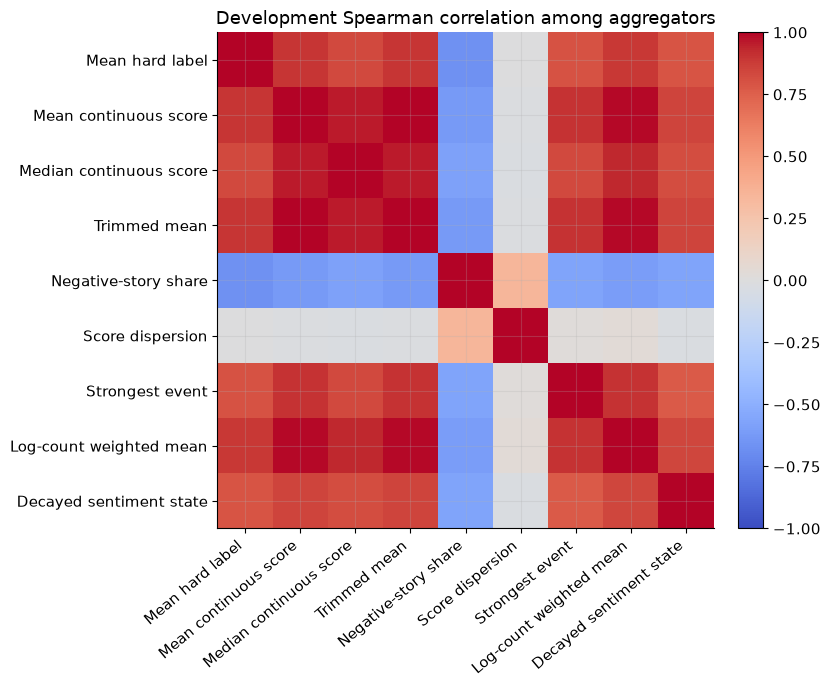

In [3]:
dev = agg.loc[agg["split"] == "development"]
corr = dev[list(AGGREGATOR_NAMES)].corr(method="spearman")
display(corr.round(3))
corr.to_csv(OUTPUT_DIR / "aggregator_corr_development.csv")

fig, ax = plt.subplots(figsize=(8.5, 7.0))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(AGGREGATOR_NAMES)))
ax.set_yticks(range(len(AGGREGATOR_NAMES)))
ax.set_xticklabels([display_label(name) for name in AGGREGATOR_NAMES], rotation=40, ha="right")
ax.set_yticklabels([display_label(name) for name in AGGREGATOR_NAMES])
ax.set_title("Development Spearman correlation among aggregators")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aggregator_corr_development.png", dpi=140)
plt.show()

## 2. Development daily cross-sectional IC vs `ar_open_h1`

Spearman correlation is computed within each session, then averaged through
time with HAC(5) SEs. BH is applied to the
nine all-n tests only. n-bin rows are descriptive — most firm-days are n≤5.

,stratum,aggregator,outcome,n,n_clusters,n_dates_total,min_names,hac_lags,inference,ic,se,t,p,bh_reject_q05,bh_family
4,all,negative_share,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,-0.0054,0.0017,-3.1189,0.0018,True,nine aggregators × primary horizon h1; n-bin s...
8,all,decayed_state,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0042,0.0019,2.2279,0.0259,False,nine aggregators × primary horizon h1; n-bin s...
2,all,median_continuous,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0035,0.0017,2.0226,0.0431,False,nine aggregators × primary horizon h1; n-bin s...
7,all,attention_log_n,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0033,0.0018,1.8094,0.0704,False,nine aggregators × primary horizon h1; n-bin s...
3,all,trimmed_mean,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0030,0.0018,1.7011,0.0889,False,nine aggregators × primary horizon h1; n-bin s...
1,all,mean_continuous,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0030,0.0018,1.6796,0.0930,False,nine aggregators × primary horizon h1; n-bin s...
0,all,mean_hard_label,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0028,0.0018,1.5766,0.1149,False,nine aggregators × primary horizon h1; n-bin s...
6,all,strongest_event,ar_open_h1,512145,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,0.0027,0.0017,1.5525,0.1205,False,nine aggregators × primary horizon h1; n-bin s...
5,all,dispersion,ar_open_h1,512149,2264,2264,3,5,mean_daily_cross_sectional_spearman_hac,-0.0015,0.0016,-0.9173,0.3590,False,nine aggregators × primary horizon h1; n-bin s...


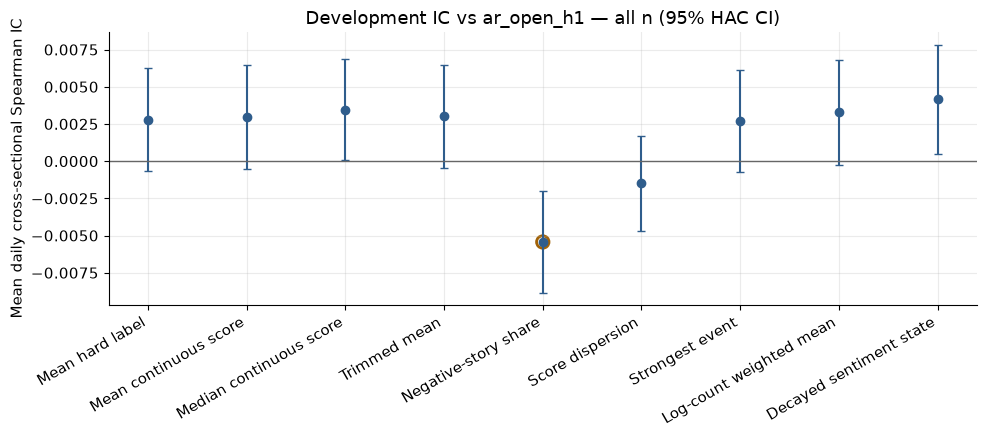

Gold ring = BH reject at q=0.05 within the nine-rule primary family.


In [4]:
ic = development_ic_table(agg, by_n_bin=True)
primary = ic.loc[ic["stratum"] == "all"].sort_values("p")
display(primary.round(4))
ic.to_csv(OUTPUT_DIR / "development_ic_by_stratum.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df = primary.set_index("aggregator").reindex(list(AGGREGATOR_NAMES))
ax.errorbar(
    range(len(plot_df)),
    plot_df["ic"],
    yerr=1.96 * plot_df["se"],
    fmt="o",
    color="#2f5d8c",
    capsize=3,
)
ax.axhline(0.0, color="#666", lw=1)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels([display_label(name) for name in plot_df.index], rotation=30, ha="right")
ax.set_ylabel("Mean daily cross-sectional Spearman IC")
ax.set_title("Development IC vs ar_open_h1 — all n (95% HAC CI)")
for i, rej in enumerate(plot_df["bh_reject_q05"].tolist()):
    if bool(rej):
        ax.scatter([i], [plot_df["ic"].iloc[i]], s=80, facecolors="none", edgecolors="#a16207", linewidths=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_ic_all_n.png", dpi=140)
plt.show()
print("Gold ring = BH reject at q=0.05 within the nine-rule primary family.")

## 3. Headline figure: IC by aggregator, faceted by n-bin

The claim that matters is often "rule X beats the mean when n is large".

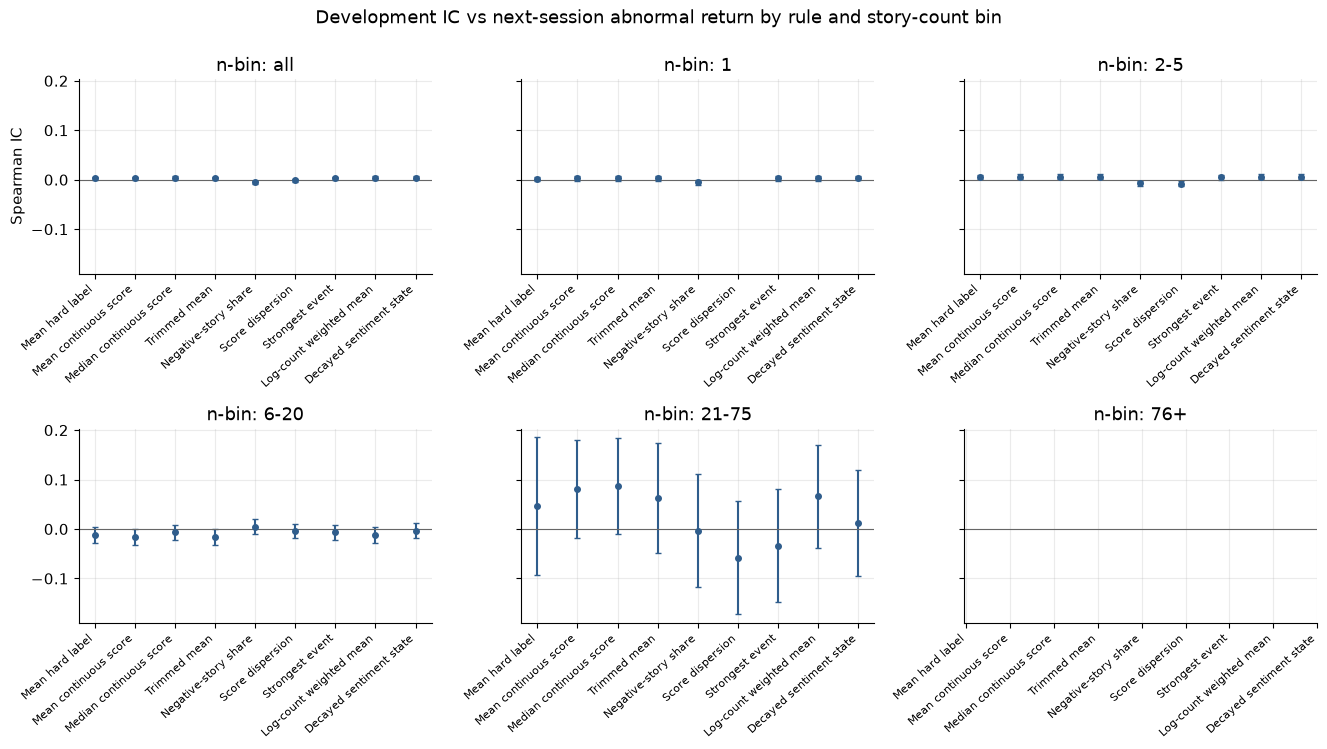

In [5]:
strata = ["all", *N_BIN_ORDER]
facet = ic.loc[ic["stratum"].isin(strata)].copy()
facet["stratum"] = pd.Categorical(facet["stratum"], categories=strata, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5), sharey=True)
axes_flat = axes.ravel()
for ax, stratum in zip(axes_flat, strata, strict=True):
    sub = facet.loc[facet["stratum"] == stratum].set_index("aggregator").reindex(list(AGGREGATOR_NAMES))
    ax.errorbar(
        range(len(sub)),
        sub["ic"],
        yerr=1.96 * sub["se"],
        fmt="o",
        color="#2f5d8c",
        capsize=2,
        markersize=4,
    )
    ax.axhline(0.0, color="#666", lw=0.8)
    ax.set_title(f"n-bin: {stratum}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([display_label(name) for name in sub.index], rotation=42, ha="right", fontsize=8)
axes_flat[0].set_ylabel("Spearman IC")
fig.suptitle("Development IC vs next-session abnormal return by rule and story-count bin", y=0.995)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_ic_by_n_bin.png", dpi=140)
plt.show()

## 4. Portfolio translation: turnover and break-even

Same development block. Rule: rank the oriented signal within each session,
centre ranks to make a dollar-neutral long/short book, weights sum `|w|=1`,
hold one session, charge
10 bps per side. Turnover is half-L1, so cost is `2 × turnover × per-side rate`
and break-even = `10000 * mean(gross) / (2 * mean(turnover))`.
Block bootstrap (length 5, 999 reps, seed 20260731) on mean daily net return.
Evaluation is not used to rank arms.

trade config: TradeConfig(threshold=0.0, cost_bps_per_side=10.0, min_names=2, annualization_periods=252, bootstrap_block_length=5, bootstrap_replications=999, random_seed=20260731, outcome='ar_open_h1', position_mode='cs_rank')
signal orientation: {'mean_hard_label': 1.0, 'mean_continuous': 1.0, 'median_continuous': 1.0, 'trimmed_mean': 1.0, 'negative_share': -1.0, 'dispersion': -1.0, 'strongest_event': 1.0, 'attention_log_n': 1.0, 'decayed_state': 1.0}


,signal,orient,ic,ic_t,bh_reject_ic_q05,mean_gross,mean_net,mean_turnover,annualized_turnover,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high,n_sessions
8,decayed_state,1.0,0.0042,2.2279,False,0.0000,-0.0012,0.6440,162.2925,0.3308,-9.8821,0.3234,-0.0013,-0.0012,2264
4,negative_share,-1.0,-0.0054,-3.1189,True,0.0001,-0.0013,0.7116,179.3307,0.6954,-10.4133,0.6253,-0.0014,-0.0012,2264
0,mean_hard_label,1.0,0.0028,1.5766,False,0.0000,-0.0016,0.8058,203.0724,0.3444,-11.4516,0.2920,-0.0017,-0.0015,2264
7,attention_log_n,1.0,0.0033,1.8094,False,0.0000,-0.0015,0.7749,195.2690,0.3185,-12.6546,0.2454,-0.0016,-0.0014,2264
6,strongest_event,1.0,0.0027,1.5525,False,0.0000,-0.0015,0.7732,194.8568,0.1512,-12.8317,0.1163,-0.0016,-0.0014,2264
3,trimmed_mean,1.0,0.0030,1.7011,False,0.0000,-0.0015,0.7841,197.5808,0.3305,-12.9729,0.2484,-0.0016,-0.0014,2264
1,mean_continuous,1.0,0.0030,1.6796,False,0.0000,-0.0015,0.7841,197.5985,0.3266,-12.9751,0.2455,-0.0016,-0.0014,2264
2,median_continuous,1.0,0.0035,2.0226,False,0.0001,-0.0015,0.7894,198.9268,0.4402,-13.3019,0.3205,-0.0016,-0.0014,2264
5,dispersion,-1.0,-0.0015,-0.9173,False,0.0000,-0.0014,0.7148,180.1259,0.3858,-13.4672,0.2786,-0.0015,-0.0013,2264


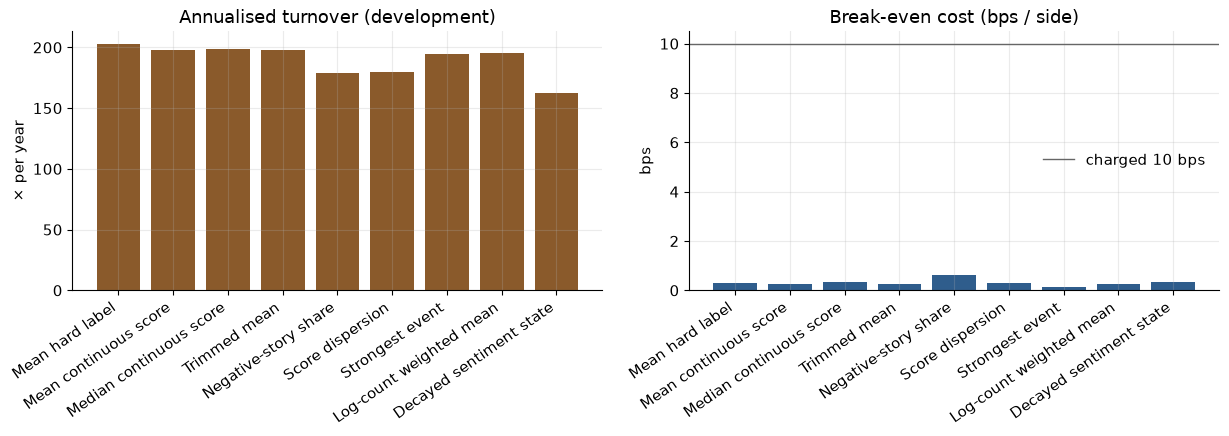

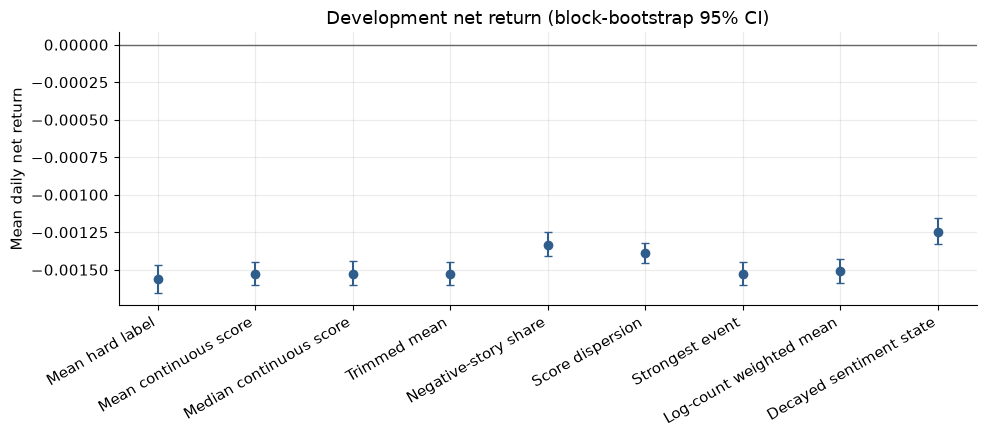

Arms with break-even > charged 10 bps: none


In [6]:
trade_cfg = TradeConfig(
    threshold=0.0,
    cost_bps_per_side=10.0,
    min_names=2,
    bootstrap_block_length=5,
    bootstrap_replications=999,
    random_seed=20260731,
    position_mode="cs_rank",
)
print("trade config:", trade_cfg)
print("signal orientation:", DEFAULT_SIGNAL_ORIENT)

arms = evaluate_aggregator_arms(agg, config=trade_cfg, split="development")
show_cols = [
    "signal",
    "orient",
    "ic",
    "ic_t",
    "bh_reject_ic_q05",
    "mean_gross",
    "mean_net",
    "mean_turnover",
    "annualized_turnover",
    "sharpe_gross",
    "sharpe_net",
    "breakeven_bps_per_side",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
    "n_sessions",
]
display(arms[show_cols].sort_values("sharpe_net", ascending=False).round(4))
arms.to_csv(OUTPUT_DIR / "development_portfolio_arms.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
rank = arms.set_index("signal").reindex(list(AGGREGATOR_NAMES))
axes[0].bar(range(len(rank)), rank["annualized_turnover"], color="#8a5a2b")
axes[0].set_xticks(range(len(rank)))
axes[0].set_xticklabels([display_label(name) for name in rank.index], rotation=35, ha="right")
axes[0].set_title("Annualised turnover (development)")
axes[0].set_ylabel("× per year")
be = rank["breakeven_bps_per_side"].astype(float)
axes[1].axhline(trade_cfg.cost_bps_per_side, color="#666", lw=1, label=f"charged {trade_cfg.cost_bps_per_side:.0f} bps")
axes[1].bar(range(len(rank)), be, color="#2f5d8c")
axes[1].set_xticks(range(len(rank)))
axes[1].set_xticklabels([display_label(name) for name in rank.index], rotation=35, ha="right")
axes[1].set_title("Break-even cost (bps / side)")
axes[1].set_ylabel("bps")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_turnover_breakeven.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(
    range(len(rank)),
    rank["mean_net"],
    yerr=[
        rank["mean_net"] - rank["bootstrap_net_ci_low"],
        rank["bootstrap_net_ci_high"] - rank["mean_net"],
    ],
    fmt="o",
    color="#2f5d8c",
    capsize=3,
)
ax.axhline(0.0, color="#666", lw=1)
ax.set_xticks(range(len(rank)))
ax.set_xticklabels([display_label(name) for name in rank.index], rotation=30, ha="right")
ax.set_ylabel("Mean daily net return")
ax.set_title("Development net return (block-bootstrap 95% CI)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "development_net_return_bootstrap.png", dpi=140)
plt.show()

viable = arms.loc[arms["breakeven_bps_per_side"].astype(float) > trade_cfg.cost_bps_per_side]
print(
    f"Arms with break-even > charged {trade_cfg.cost_bps_per_side:.0f} bps: "
    + (", ".join(viable["signal"].tolist()) if len(viable) else "none")
)

## 5. Nulls and incumbent check

If `mean_hard_label` wins (or nothing survives costs), that is the result.

In [7]:
summary_rows = []
for name in AGGREGATOR_NAMES:
    row = primary.loc[primary["aggregator"] == name].iloc[0]
    arm = arms.loc[arms["signal"] == name].iloc[0]
    summary_rows.append(
        {
            "aggregator": name,
            "ic": row["ic"],
            "t": row["t"],
            "p": row["p"],
            "bh_reject_q05": bool(row["bh_reject_q05"]),
            "orient": float(arm["orient"]),
            "mean_net": float(arm["mean_net"]),
            "sharpe_net": float(arm["sharpe_net"]),
            "annualized_turnover": float(arm["annualized_turnover"]),
            "breakeven_bps_per_side": arm["breakeven_bps_per_side"],
            "beats_10bps": (
                arm["breakeven_bps_per_side"] is not None
                and float(arm["breakeven_bps_per_side"]) > trade_cfg.cost_bps_per_side
            ),
            "n": int(row["n"]),
            "n_clusters": int(row["n_clusters"]),
        }
    )
summary = pd.DataFrame(summary_rows).sort_values("ic", key=lambda s: s.abs(), ascending=False)
display(summary.round(4))
summary.to_csv(OUTPUT_DIR / "development_ic_primary_ranked.csv", index=False)

incumbent = summary.loc[summary["aggregator"] == "mean_hard_label"].iloc[0]
winners = summary.loc[summary["bh_reject_q05"]]
print(
    f"Incumbent mean_hard_label: IC={incumbent['ic']:.4f}  "
    f"t={incumbent['t']:.2f}  BH={incumbent['bh_reject_q05']}  "
    f"net Sharpe={incumbent['sharpe_net']:.3f}  "
    f"break-even={incumbent['breakeven_bps_per_side']}"
)
if winners.empty:
    print("No aggregator rejects BH at q=0.05 on development all-n. Null stands.")
else:
    print("BH survivors:", ", ".join(winners["aggregator"].tolist()))
cost_ok = summary.loc[summary["beats_10bps"]]
print(
    "Break-even > 10 bps:",
    (", ".join(cost_ok["aggregator"].tolist()) if len(cost_ok) else "none"),
)

# Evaluation block is present on disk but intentionally not ranked here.
eval_n = int((agg["split"] == "evaluation").sum())
print(f"Evaluation firm-days held out from ranking: {eval_n:,}")

,aggregator,ic,t,p,bh_reject_q05,orient,mean_net,sharpe_net,annualized_turnover,breakeven_bps_per_side,beats_10bps,n,n_clusters
4,negative_share,-0.0054,-3.1189,0.0018,True,-1.0,-0.0013,-10.4133,179.3307,0.6253,False,512149,2264
8,decayed_state,0.0042,2.2279,0.0259,False,1.0,-0.0012,-9.8821,162.2925,0.3234,False,512149,2264
2,median_continuous,0.0035,2.0226,0.0431,False,1.0,-0.0015,-13.3019,198.9268,0.3205,False,512149,2264
7,attention_log_n,0.0033,1.8094,0.0704,False,1.0,-0.0015,-12.6546,195.2690,0.2454,False,512149,2264
3,trimmed_mean,0.0030,1.7011,0.0889,False,1.0,-0.0015,-12.9729,197.5808,0.2484,False,512149,2264
1,mean_continuous,0.0030,1.6796,0.0930,False,1.0,-0.0015,-12.9751,197.5985,0.2455,False,512149,2264
0,mean_hard_label,0.0028,1.5766,0.1149,False,1.0,-0.0016,-11.4516,203.0724,0.2920,False,512149,2264
6,strongest_event,0.0027,1.5525,0.1205,False,1.0,-0.0015,-12.8317,194.8568,0.1163,False,512145,2264
5,dispersion,-0.0015,-0.9173,0.3590,False,-1.0,-0.0014,-13.4672,180.1259,0.2786,False,512149,2264


Incumbent mean_hard_label: IC=0.0028  t=1.58  BH=False  net Sharpe=-11.452  break-even=0.29198218425788947
BH survivors: negative_share
Break-even > 10 bps: none
Evaluation firm-days held out from ranking: 203,393


In [8]:
manifest = {
    "notebook": "03_aggregation",
    "built_for": "Workstream 3 aggregation comparison (development-only ranking)",
    "primary_spine": "FNSPID",
    "primary_outcome": PRIMARY_OUTCOME,
    "primary_horizon": PRIMARY_HORIZON,
    "sensitivity_horizons": [],
    "frozen_split": {
        "development_end": FROZEN_DEV_END,
        "evaluation_start": FROZEN_EVAL_START,
        "evaluation_used_for_ranking": False,
    },
    "inference": {
        "ic": "mean_daily_cross_sectional_spearman_hac5",
        "portfolio_net": "circular_block_bootstrap",
        "bootstrap_block_length": trade_cfg.bootstrap_block_length,
        "bootstrap_replications": trade_cfg.bootstrap_replications,
        "bootstrap_seed": trade_cfg.random_seed,
    },
    "portfolio_rule": {
        "type": "cross_sectional_rank_dollar_neutral_long_short",
        "threshold": trade_cfg.threshold,
        "cost_bps_per_side": trade_cfg.cost_bps_per_side,
        "orient": DEFAULT_SIGNAL_ORIENT,
    },
    "multiplicity_family": MULTIPLICITY_FAMILY,
    "fdr": "benjamini_hochberg_q_0.05_on_nine_all_n_tests",
    "aggregators": list(AGGREGATOR_NAMES),
    "n_firm_days": int(len(agg)),
    "n_development": int((agg["split"] == "development").sum()),
    "n_evaluation_held_out": eval_n,
    "deferred": [
        "publisher_attention_weights",
        "longer_horizons",
    ],
    "primary_ic_ranked": summary.to_dict(orient="records"),
    "analysis_status": "exploratory_repaired_2026-07-31",
    "supersedes": "outputs/superseded/20260731_pre_rigour_repair/03_aggregation",
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n")
print(json.dumps({k: manifest[k] for k in ("primary_outcome", "n_firm_days", "deferred")}, indent=2))

{
  "primary_outcome": "ar_open_h1",
  "n_firm_days": 715546,
  "deferred": [
    "publisher_attention_weights",
    "longer_horizons"
  ]
}


### Carry-forward

1. Development IC + BH + turnover/break-even is the W3 scorecard.
2. Re-read the n-bin facet before claiming a global winner — low-n days dominate.
3. Evaluation remains sealed for ranking; open it only after the rule set and
   multiplicity family are frozen (Gate F1 / promotion).
4. The portfolio is the corrected `position_mode="cs_rank"` specification.
   Read `05_interpretation` for redundancy and count-confounding diagnostics:
   the nine rules are only ~4 effective tests, and dispersion is strongly
   correlated with story count.
5. Next listed workstream: surprise stack (`04_surprise`).